# Notebook 04: Model Training and Hyperparameter Tuning

**Deskripsi:** Notebook ini memuat matriks fitur numerik terkompresi dari `data/processed/extracted_features.joblib`, melakukan eksperimen klasifikasi komparatif menggunakan 4 model Machine Learning (**Logistic Regression, LinearSVC, Complement Naive Bayes (CNB), dan Random Forest**), mencari kombinasi parameter terbaik menggunakan **GridSearchCV (5-Fold Stratified CV)** berorientasi **Macro F1-Score**, merangkum hasil dalam tabel komparasi kinerja, dan memfinalisasi serta menyimpan model terbaik ke `models/best_ml_model.joblib`.

In [1]:
import sys
import os
os.makedirs('../reports/figures', exist_ok=True)
import joblib
import numpy as np
import pandas as pd

# Tambahkan path parent directory agar modul 'src' bisa diimpor
sys.path.append(os.path.abspath('../'))
from src.modeling import train_with_grid_search, evaluate_model

print("Modul pemodelan berhasil dimuat!")


Modul pemodelan berhasil dimuat!


## 1. Memuat Matriks Fitur Terkompresi

In [2]:
features_path = '../data/processed/extracted_features.joblib'
features = joblib.load(features_path)

print("Daftar matriks fitur yang berhasil dimuat:")
for key in features.keys():
    if hasattr(features[key], 'shape'):
        shape = features[key].shape
    else:
        shape = len(features[key])
    print(f"- {key} | Dimensi: {shape}")

Daftar matriks fitur yang berhasil dimuat:
- X_train_tfidf | Dimensi: (12772, 15654)
- X_val_tfidf | Dimensi: (2737, 15654)
- X_test_tfidf | Dimensi: (2738, 15654)
- X_train_w2v_avg | Dimensi: (12772, 100)
- X_val_w2v_avg | Dimensi: (2737, 100)
- X_test_w2v_avg | Dimensi: (2738, 100)
- X_train_w2v_weighted | Dimensi: (12772, 100)
- X_val_w2v_weighted | Dimensi: (2737, 100)
- X_test_w2v_weighted | Dimensi: (2738, 100)
- y_train | Dimensi: (12772,)
- y_val | Dimensi: (2737,)
- y_test | Dimensi: (2738,)


## 2. Eksperimen Klasifikasi Komparatif (Grid Search & Evaluation)

Kita mendefinisikan loop uji coba untuk melatih model berdasarkan kombinasi representasi fitur dan algoritma pengklasifikasi. Hasil evaluasi dicatat pada set validasi (`val`).

In [3]:
# Daftar kombinasi eksperimen
# Format: (feature_key_name, feature_key_train, feature_key_val)
feature_configs = [
    ('tfidf', 'X_train_tfidf', 'X_val_tfidf'),
    ('w2v_average', 'X_train_w2v_avg', 'X_val_w2v_avg'),
    ('w2v_weighted', 'X_train_w2v_weighted', 'X_val_w2v_weighted')
]

models_list = ["LogisticRegression", "LinearSVC", "ComplementNB", "RandomForest"]

results = []
trained_models = {}

for feat_name, train_key, val_key in feature_configs:
    X_train = features[train_key]
    X_val = features[val_key]
    # Konversi label dari tipe PyArrow Extension Array ke standar NumPy String untuk mencegah error pengindeksan cross-validation
    y_train = np.array(features['y_train']).astype(str)
    y_val = np.array(features['y_val']).astype(str)
    
    for model_name in models_list:
        # Restriksi Aturan Kompatibilitas 1: ComplementNB hanya berjalan pada TF-IDF
        if model_name == "ComplementNB" and feat_name != "tfidf":
            continue
            
        # Latih model menggunakan GridSearchCV
        try:
            best_model = train_with_grid_search(model_name, feat_name, X_train, y_train)
            
            # Evaluasi pada set validasi
            macro_f1, accuracy = evaluate_model(best_model, X_val, y_val)
            
            print(f"Evaluasi Val - Macro F1: {macro_f1:.4f} | Akurasi: {accuracy:.4f}")
            print("=" * 60)
            
            # Catat hasil
            results.append({
                'Fitur': feat_name,
                'Model': model_name,
                'Val Macro F1': round(macro_f1, 4),
                'Val Accuracy': round(accuracy, 4)
            })
            
            # Simpan model sementara dalam memori
            trained_models[f"{feat_name}_{model_name}"] = best_model
            
        except Exception as e:
            print(f"Error saat melatih {model_name} dengan fitur {feat_name}: {e}")
            print("=" * 60)

Menjalankan GridSearch untuk LogisticRegression (tfidf)...


Hyperparameter terbaik: {'C': 10.0}
Best CV Macro F1: 0.9328
Evaluasi Val - Macro F1: 0.9285 | Akurasi: 0.9580
Menjalankan GridSearch untuk LinearSVC (tfidf)...


Hyperparameter terbaik: {'C': 10.0}
Best CV Macro F1: 0.9427
Evaluasi Val - Macro F1: 0.9414 | Akurasi: 0.9664
Menjalankan GridSearch untuk ComplementNB (tfidf)...
Hyperparameter terbaik: {'alpha': 0.5}
Best CV Macro F1: 0.8228
Evaluasi Val - Macro F1: 0.8219 | Akurasi: 0.8845
Menjalankan GridSearch untuk RandomForest (tfidf)...


Hyperparameter terbaik: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Macro F1: 0.8497
Evaluasi Val - Macro F1: 0.8510 | Akurasi: 0.8981
Menjalankan GridSearch untuk LogisticRegression (w2v_average)...


Hyperparameter terbaik: {'C': 10.0}
Best CV Macro F1: 0.7828
Evaluasi Val - Macro F1: 0.7638 | Akurasi: 0.8381
Menjalankan GridSearch untuk LinearSVC (w2v_average)...


Hyperparameter terbaik: {'C': 10.0}
Best CV Macro F1: 0.7904
Evaluasi Val - Macro F1: 0.7731 | Akurasi: 0.8520
Menjalankan GridSearch untuk RandomForest (w2v_average)...


Hyperparameter terbaik: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Macro F1: 0.6983
Evaluasi Val - Macro F1: 0.6906 | Akurasi: 0.7837
Menjalankan GridSearch untuk LogisticRegression (w2v_weighted)...


Hyperparameter terbaik: {'C': 10.0}
Best CV Macro F1: 0.7121
Evaluasi Val - Macro F1: 0.7004 | Akurasi: 0.7830
Menjalankan GridSearch untuk LinearSVC (w2v_weighted)...


Hyperparameter terbaik: {'C': 10.0}
Best CV Macro F1: 0.7201
Evaluasi Val - Macro F1: 0.7108 | Akurasi: 0.7969
Menjalankan GridSearch untuk RandomForest (w2v_weighted)...


Hyperparameter terbaik: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Macro F1: 0.6599
Evaluasi Val - Macro F1: 0.6522 | Akurasi: 0.7468


## 3. Hasil Perbandingan Kinerja Model (Tabel Komparasi)

In [4]:
df_results = pd.DataFrame(results)
df_results_sorted = df_results.sort_values(by='Val Macro F1', ascending=False)

print("--- TABEL HASIL KOMPARASI MODEL (SET VALIDASI) ---")
print(df_results_sorted.to_string(index=False))

--- TABEL HASIL KOMPARASI MODEL (SET VALIDASI) ---
       Fitur              Model  Val Macro F1  Val Accuracy
       tfidf          LinearSVC        0.9414        0.9664
       tfidf LogisticRegression        0.9285        0.9580
       tfidf       RandomForest        0.8510        0.8981
       tfidf       ComplementNB        0.8219        0.8845
 w2v_average          LinearSVC        0.7731        0.8520
 w2v_average LogisticRegression        0.7638        0.8381
w2v_weighted          LinearSVC        0.7108        0.7969
w2v_weighted LogisticRegression        0.7004        0.7830
 w2v_average       RandomForest        0.6906        0.7837
w2v_weighted       RandomForest        0.6522        0.7468


## 3.1 Visualisasi Grafik Batang Komparatif Performa Model

Kami memvisualisasikan performa F1 Macro dari seluruh model dalam bentuk grouped bar chart untuk mempermudah perbandingan visual.

Grafik perbandingan model disimpan ke: reports/figures/model_comparison_chart.png


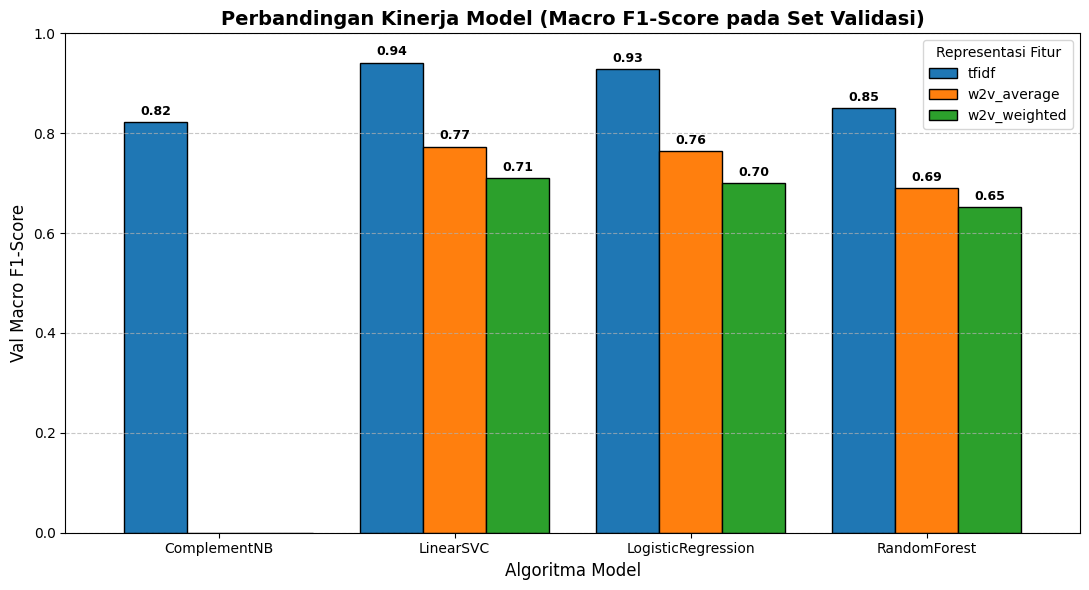

In [5]:
# Visualisasi Grafik Batang Komparatif Performa Model
try:
    import matplotlib.pyplot as plt
    
    # Pivot data untuk mempermudah penggambaran grouped bar chart
    df_pivot = df_results.pivot(index='Model', columns='Fitur', values='Val Macro F1')
    
    # Plot grouped bar chart
    ax = df_pivot.plot(kind='bar', figsize=(11, 6), edgecolor='black', width=0.8)
    plt.title('Perbandingan Kinerja Model (Macro F1-Score pada Set Validasi)', fontsize=14, fontweight='bold')
    plt.xlabel('Algoritma Model', fontsize=12)
    plt.ylabel('Val Macro F1-Score', fontsize=12)
    plt.xticks(rotation=0)
    plt.ylim(0, 1.0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title='Representasi Fitur')
    
    # Tambahkan label angka di atas setiap batang
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.2f}',
                        xy=(p.get_x() + p.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, fontweight='bold')
            
    plt.tight_layout()
    # Simpan grafik perbandingan untuk paper/slide
    plt.savefig('../reports/figures/model_comparison_chart.png', dpi=300, bbox_inches='tight')
    print("Grafik perbandingan model disimpan ke: reports/figures/model_comparison_chart.png")
    plt.show()
except Exception as e:
    print(f"[WARNING] Gagal menggambar grafik batang komparatif: {e}")


## 4. Evaluasi Akhir Model Terbaik pada Test Set

Kita mengambil konfigurasi model-fitur terbaik dari tabel komparasi untuk diuji kinerjanya pada set uji alami (`test`).

In [6]:
best_row = df_results_sorted.iloc[0]
best_config_key = f"{best_row['Fitur']}_{best_row['Model']}"
best_model_estimator = trained_models[best_config_key]

print(f"Model Terbaik Terpilih : {best_row['Model']}")
print(f"Representasi Fitur    : {best_row['Fitur']}")
print(f"Skor Macro F1 Val     : {best_row['Val Macro F1']:.4f}")

# Tentukan key pemetaan fitur untuk Test set
test_feat_map = {
    'tfidf': 'X_test_tfidf',
    'w2v_average': 'X_test_w2v_avg',
    'w2v_weighted': 'X_test_w2v_weighted'
}

X_test = features[test_feat_map[best_row['Fitur']]]
y_test = np.array(features['y_test']).astype(str)

# Evaluasi final pada set uji (Test set)
test_macro_f1, test_accuracy = evaluate_model(best_model_estimator, X_test, y_test)

print("\n--- EVALUASI FINAL PADA TEST SET ---")
print(f"Test Macro F1 : {test_macro_f1:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

Model Terbaik Terpilih : LinearSVC
Representasi Fitur    : tfidf
Skor Macro F1 Val     : 0.9414

--- EVALUASI FINAL PADA TEST SET ---
Test Macro F1 : 0.9407
Test Accuracy : 0.9675


## 5. Serialisasi Model Terbaik

Kita menyimpan model biner terbaik beserta informasi metadata konfigurasinya ke dalam berkas `models/best_ml_model.joblib`.

In [7]:
best_model_payload = {
    'model': best_model_estimator,
    'feature_type': best_row['Fitur'],
    'val_macro_f1': best_row['Val Macro F1'],
    'test_macro_f1': test_macro_f1
}

joblib.dump(best_model_payload, '../models/best_ml_model.joblib')
print("Model klasifikasi emosi terbaik berhasil disimpan ke models/best_ml_model.joblib!")

Model klasifikasi emosi terbaik berhasil disimpan ke models/best_ml_model.joblib!
